<a href="https://colab.research.google.com/github/lokNezMonzter/llm-fine-tuning/blob/develop/fine_tune_llama_3_2_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# Ignore or supress warnings
import warnings
warnings.filterwarnings('ignore')

# Installation

In [1]:
%%capture
!pip install -q pip3-autoremove
!pip-autoremove torch torchvision torchaudio -y
!pip install -q torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu121
!pip install unsloth

# Initialize Model

In [5]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre-quantized models supproted for 4x faster download
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
]

# Initialize model and tokenizer
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Llama-3.2-11B-Vision-Instruct",
    load_in_4bit=True, # Use 4bit to reduce memory use; False for 16bit LoRA
    use_gradient_checkpointing="unsloth",
)

==((====))==  Unsloth 2025.6.4: Fast Mllama patching. Transformers: 4.52.4.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 8.0. CUDA Toolkit: 12.1. Triton: 3.1.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


/usr/local/lib/python3.11/dist-packages/transformers/quantizers/auto.py:222: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors.index.json:   0%|          | 0.00/375k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.94G [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.9k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.15k [00:00<?, ?B/s]

# Model Configuration

Add LoRA adapters for parameter efficient fine-tuning. This allows us to efficiently train only 1% of the parameters

In [6]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,

    r=16, # Larger values of r give better accuracy but may lead to overfitting
    lora_alpha=32, # Recommended alha == r at least
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False, # rank stabilized LoRA
    loftq_config=None
)

Unsloth: Making `model.base_model.model.model.vision_model.transformer` require gradients


# Data Preparation

We are using a sampled version of the ROCO radiography dataset. The dataset includes X-Rays, CT scans and ultrasounds showcasing medical conditions and diseases.  

Each image has a caption written by experts describing it. The goal is to finetune a VLM to make it a useful analysis tool for medical professionals.

In [7]:
from datasets import load_dataset
dataset = load_dataset("unsloth/Radiology_mini", split="train")
dataset

README.md:   0%|          | 0.00/610 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/79.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1978 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/327 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'image_id', 'caption', 'cui'],
    num_rows: 1978
})

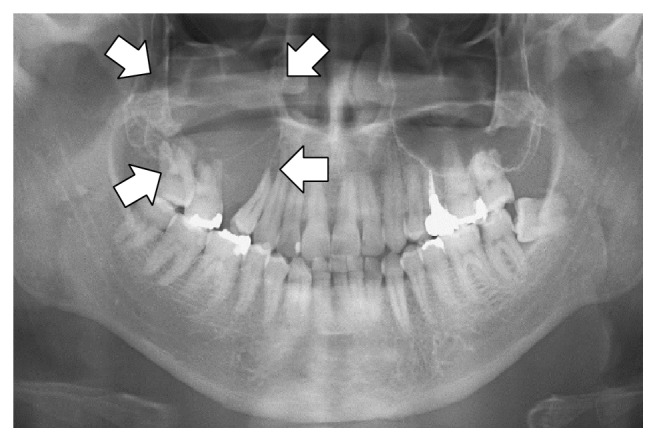

In [8]:
dataset[0]["image"]

In [9]:
dataset[0]["caption"]

'Panoramic radiography shows an osteolytic lesion in the right posterior maxilla with resorption of the floor of the maxillary sinus (arrows).'

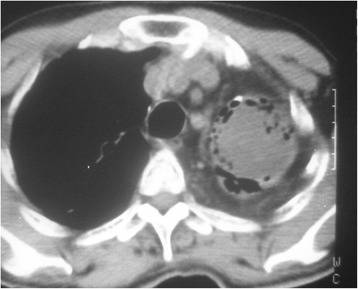

In [13]:
dataset[42]["image"]

In [14]:
dataset[42]["caption"]

'Computed tomographic view of a complex aspergilloma of the left lung'

Format the dataset as per the vision fine-tuning format mentioned below:  

```python
[
  {
    "role": "user",
    "content": [
      {"type": "text",  "text": instruction},
      {"type": "image", "image": image}
    ]
  },
  {
    "role": "assistant",
    "content": [{"type": "text",  "text": answer} ]
  },
]
```

We will craft a custom instruction asking the VLM to be an expert radiographer. Instead of just 1 instruction, we can also add multiple turns to make it a dynamic conversation.  

In [16]:
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

def convert_to_conversation(sample):
  conversation = [
      {
          "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]}
          ]
      },
      {
          "role" : "assistant",
          "content" : [
          {"type" : "text",  "text"  : sample["caption"]}
        ]
      },
  ]
  return {"messages": conversation}

In [17]:
# Convert the dataset into VLM format
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

In [19]:
converted_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'You are an expert radiographer. Describe accurately what you see in this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=657x442>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': 'Panoramic radiography shows an osteolytic lesion in the right posterior maxilla with resorption of the floor of the maxillary sinus (arrows).'}]}]}

# Intermediate Inferencing

Maybe the VLM already knows how to analyse the images? Let's do some inferencing to find out!

In [20]:
FastVisionModel.for_inference(model) # Enable for inference

image = dataset[0]["image"]
instruction = instruction

messages = [
    {"role": "user", "content": [{"type": "text", "text": instruction}, {"type": "image"}]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True)
_ = model.generate(
      **inputs,
      streamer=text_streamer,
      max_new_tokens=128,
      use_cache=True,
      temperature=1.5,
      min_p=0.1
    )


This radiograph appears to be a panoramic view of the upper jaw. The right and left condyle is located at the top and are represented as small dark circles in a triangular formation.

Below the condyle on each side are two teeth on the front tooth area, four teeth in the molar region. Behind those, there is a solid structure that represents the bone between the left and right sinus. It is clear that one side appears significantly smaller than the other, suggesting that one may have a greater quantity of teeth. One of the four molar teeth in this sinus appears to be broken or damaged in the left side. 

In the


# Train The Model

Use Huggingface TRL's SFFTTrainer. For a full run, set `num_train_epochs=1` and `max_steps=None` and for a quick training loop we can use 60 steps instead of a full epoch.

In [26]:
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=converted_dataset,
    args=SFTConfig(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        # max_steps=60, # For a quick training run
        num_train_epochs=1,
        learning_rate=2e-4,
        bf16=is_bf16_supported(),
        fp16=not is_bf16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="output",
        report_to="none", # Disable reporting results on Weights and Biases

        # Must required config arguments for vision fine tuning
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        dataset_num_proc=4,
        max_seq_length=2048
    ),
)

average_tokens_across_devices is set to True but it is invalid when world size is1. Turn it to False automatically.


In [27]:
#@title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A100-SXM4-40GB. Max memory = 39.557 GB.
10.279 GB of memory reserved.


In [28]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,978 | Num Epochs = 1 | Total steps = 495
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 67,174,400/11,000,000,000 (0.61% trained)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632

Step,Training Loss
1,3.825600
2,3.343000
3,3.575600
4,2.903400
5,2.577500
6,2.134000
7,1.809400
8,1.328900
9,1.257200
10,1.373800


In [29]:
#@title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory         /max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

4041.8387 seconds used for training.
67.36 minutes used for training.
Peak reserved memory = 10.279 GB.
Peak reserved memory for training = 0.0 GB.
Peak reserved memory % of max memory = 25.985 %.
Peak reserved memory for training % of max memory = 0.0 %.


# Inferencing

Use the fine-tuned model for inferencing! Set `min_p=0.01` and `temperature=1.5`

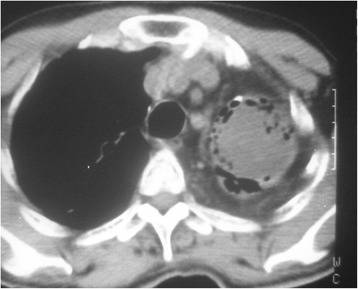

In [36]:
dataset[42]["image"]

In [37]:
dataset[42]["caption"]

'Computed tomographic view of a complex aspergilloma of the left lung'

In [38]:
FastVisionModel.for_inference(model) # Enable for inference

image = dataset[42]["image"]
instruction = "You are an expert radiographer. Describe accurately what you see in this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True, use_reentrant=False)
_ = model.generate(
    **inputs,
    streamer=text_streamer,
    max_new_tokens=128,
    use_cache=True,
    temperature=1.5,
    min_p=0.01,
)

Computed tomography showing extensive left lower lobe consolidation, cavity formation, and air space consolidation in acute pneumonia.<|eot_id|>


In [56]:
from PIL import Image

def generate_prediction(image, caption):
  print(caption)
  print("\n######PREDICTION######\n")

  inputs = tokenizer(
      image,
      input_text,
      add_special_tokens=False,
      return_tensors="pt"
  ).to("cuda")

  text_streamer = TextStreamer(tokenizer, skip_prompt=True)
  _ = model.generate(
      **inputs,
      streamer=text_streamer,
      max_new_tokens=128,
      use_cache=True,
      temperature=1.5,
      min_p=0.01
  )

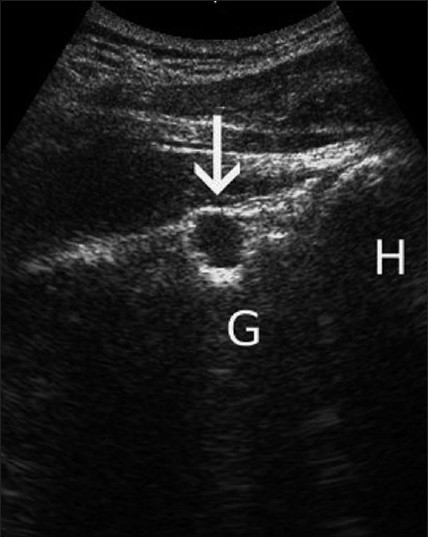

In [59]:
dataset[85]["image"]

In [60]:
generate_prediction(dataset[85]["image"], dataset[85]["caption"])

The spinoglenoid notch is shown and a cyst (arrow) is visualized in this region (G: Glenoid; H: Humeral head)

######PREDICTION######

Ultrasound abdomen images (long axis). The ultrasound shows 3cm long gallstone lying close to gallbladder anterior wall. H-Hepato (Liver), G-Gallbladder, White arrow-Gallstone<|eot_id|>
